<p align="left">
<img src="https://raw.githubusercontent.com/dewdotninja/exams/main/feng_heading_en.png" width=400 alt="Feng heading"/>
</p>

#### Department of Mechanical Engineering

### Homework 3
Second Semester, Academic Year 2025

<br>**01208583 Robotics**

พิมพ์ชื่อ - นามสกุล และรหัสนิสิตในเซลล์ด้านล่างนี้ (สำคัญ หากเว้นว่างไว้หัก 1 คะแนน)


In [1]:
# ชื่อ นามสกุล รหัสนิสิต

**คำสั่ง :** โน๊ตบุคนี้ประกอบด้วยส่วนที่เป็นเนื้อหาสำหรับอ่าน และส่วนที่ผู้เรียนต้องพิมพ์คำตอบ หรือเขียนโค้ดไพทอนเพื่อได้คะแนนตามที่ระบุ โดยจะเป็นส่วนที่อยู่ภายใต้คำว่า **Solution** โจทย์ปัญหามี 3 ข้อย่อย คือ 

* [P1](#p1) 5 คะแนน
* [P2](#p2) 3 คะแนน
* [P3](#p3) 2 คะแนน

อ่านคำสั่งตรงส่วนที่เป็นคะแนนให้เข้าใจชัดเจนว่าโจทย์ต้องการเอาต์พุตอะไร แล้วเขียนโค้ดเพื่อให้ได้เอาต์พุตนั้น เอาต์พุตที่ถูกต้องจะต้องค้างอยู่ใน notebook นี้โดยผู้ตรวจไม่ต้องรันใหม่ 
นอกจากเป็นที่สงสัย อาจจะรันโน๊ตบุคใหม่ตั้งแต่เซลล์บนสุด 
เซลล์ใดที่มีคะแนนและมีเอาต์พุตเป็น error message จะได้คะแนนศูนย์ทันที   

***

<a id="p1"></a>

## P1 (5 คะแนน)

จากเว็บของแพ็กเกจ [OSQP](https://osqp.org/) มี [ตัวอย่างตัวควบคุมทำนายโมเดล (MPC)](https://osqp.org/docs/examples/mpc.html) สำหรับโดรน 3 มิติ โดยโค้ดค่อนข้างสมบูรณ์สามารถทำงานได้ ขาดเพียงคำอธิบาย 

1. ศึกษาโค้ดนี้โดยแบ่งออกเป็นส่วนย่อย โดยสร้าง markdown cell อธิบายแต่ละส่วนให้ชัดเจน (2 คะแนน)
2. เนื่องจากพลานต์ที่ให้มาอยู่ในรูปดีสครีต เป็นการยากที่จะเข้าใจพลวัตและการนิยามสถานะจากความสัมพันธ์ทางฟิสิกส์ อย่างไรก็ตามจากการทดสอบพอคาดเดาได้ว่าสถานะที่เป็นตำแหน่ง $p_x,p_y,p_z$ ของโดรนในระบบสามมิติสอดคล้องกับตัวชี้ที่ 3,4,2 ในเวกเตอร์สถานะ $x$ (ตัวชี้ของไพทอนเริ่มจาก 0) ทดลองพล็อตค่าดัชนีอื่นในเวกเตอร์สถานะและวิเคราะห์ว่าค่าใดเป็นค่ามุม ความเร็วเชิงเส้น ความเร็วเชิงมุม
กำหนดค่าอ้างอิงที่ต้องการให้โดรนไปลอยตัวอยู่ที่ตำแหน่งสุดท้าย เช่น [2.0, 1.0, 3.0] รันอัลอกริทึมเป็นจำนวนขั้นเวลาที่ต้องการ เช่น 50 ขั้น หาคำตอบสำหรับเวกเตอร์ตัวควบคุมเหมาะที่สุด uvec และเก็บค่าเวกเตอร์สถานะ xvec  พล็อตค่าของตำแหน่งและความเร็ว (เชิงเส้นและเชิงมุมแยกจากกัน จะมีทั้งหมด 4 พล็อต)และค่าตัวควบคุมสำหรับใบพัดทั้ง 4 เทียบกับตัวชี้ขั้นเวลา (3 คะแนน)

### Solution

อ้างอิงจากตัวอย่างของ MPC ตามลิงก์ด้านบน โจทย์ปัญหาคือ สำหรับสถานะ $x_k \in \mathbb{R}^{n_x}$ สถานะอ้างอิงและเริ่มต้น  $x_r, x_0 \ \in \mathbb{R}^{n_x}$ และอินพุตควบคุม $u_k \in \mathbb{R}^{n_u}$
$$
\underset{x,u}{min} \; (x_N - x_r)^TQ_N(x_N - x_r) + \sum_{k=0}^{N-1}(x_k - x_r)^TQ(x_k-x_r) + u_k^TRu_k \tag{3.1}
$$
ภายใต้เงื่อนไข
$$
\begin{align*}
&x_{k+1} = Ax_k + Bu_k \\
&x_{min} \le x_k \le x_{max} \\
&u_{min} \le u_k \le u_{max} \\
&x_{initial} = x_0
\end{align*} \tag{3.2}
$$

นำเข้าแพ็กเกจที่ต้องการใช้ โดยเฉพาะตัวแก้ปัญหา osqp ซึ่งหากยังไม่ได้ติดตั้งต้องใช้คำสั่ง

```python
!pip install osqp
```

In [2]:
import osqp
import numpy as np
import scipy as sp
from scipy import sparse

ในตัวอย่างนี้ใช้ข้อมูลของควอดโรเตอร์ที่ประมาณค่าเชิงเส้นและแปลงเป็นระบบดีสครีตแล้ว นิยามเป็นเมทริกซฺ์มากเลขศูนย์โดยใช้ sparse.csc_matrix()

In [3]:
# Discrete time model of a quadcopter
Ad = sparse.csc_matrix([
  [1.,      0.,     0., 0., 0., 0., 0.1,     0.,     0.,  0.,     0.,     0.    ],
  [0.,      1.,     0., 0., 0., 0., 0.,      0.1,    0.,  0.,     0.,     0.    ],
  [0.,      0.,     1., 0., 0., 0., 0.,      0.,     0.1, 0.,     0.,     0.    ],
  [0.0488,  0.,     0., 1., 0., 0., 0.0016,  0.,     0.,  0.0992, 0.,     0.    ],
  [0.,     -0.0488, 0., 0., 1., 0., 0.,     -0.0016, 0.,  0.,     0.0992, 0.    ],
  [0.,      0.,     0., 0., 0., 1., 0.,      0.,     0.,  0.,     0.,     0.0992],
  [0.,      0.,     0., 0., 0., 0., 1.,      0.,     0.,  0.,     0.,     0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      1.,     0.,  0.,     0.,     0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      0.,     1.,  0.,     0.,     0.    ],
  [0.9734,  0.,     0., 0., 0., 0., 0.0488,  0.,     0.,  0.9846, 0.,     0.    ],
  [0.,     -0.9734, 0., 0., 0., 0., 0.,     -0.0488, 0.,  0.,     0.9846, 0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      0.,     0.,  0.,     0.,     0.9846]
])
Bd = sparse.csc_matrix([
  [0.,      -0.0726,  0.,     0.0726],
  [-0.0726,  0.,      0.0726, 0.    ],
  [-0.0152,  0.0152, -0.0152, 0.0152],
  [-0.,     -0.0006, -0.,     0.0006],
  [0.0006,   0.,     -0.0006, 0.0000],
  [0.0106,   0.0106,  0.0106, 0.0106],
  [0,       -1.4512,  0.,     1.4512],
  [-1.4512,  0.,      1.4512, 0.    ],
  [-0.3049,  0.3049, -0.3049, 0.3049],
  [-0.,     -0.0236,  0.,     0.0236],
  [0.0236,   0.,     -0.0236, 0.    ],
  [0.2107,   0.2107,  0.2107, 0.2107]])
[nx, nu] = Bd.shape

สังเกตว่าจากตัวอย่างนี้ไม่มีข้อมูลการนิยามสถานะ ซึ่งโจทย์การบ้านนี้ต้องการให้เราตรวจสอบเพื่อพล็อตผลตอบสนองได้ถูกต้อง ซึ่งจะได้ดำเนินการในลำดับต่อไป ในขั้นนี้จะอธิบายโค้ดที่ให้มาในตัวอย่างก่อน โดยโค้ดในบล็อกต่อมาคือการนิยามค่าเริ่มต้นของอินพุตตัวควบคุม และเงื่อนไขบังคับที่เป็นขอบเขตของอินพุตและสถานะ

In [4]:
# Constraints
u0 = 10.5916
umin = np.array([9.6, 9.6, 9.6, 9.6]) - u0
umax = np.array([13., 13., 13., 13.]) - u0
xmin = np.array([-np.pi/6,-np.pi/6,-np.inf,-np.inf,-np.inf,-1.,
                 -np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf])
xmax = np.array([ np.pi/6, np.pi/6, np.inf, np.inf, np.inf, np.inf,
                  np.inf, np.inf, np.inf, np.inf, np.inf, np.inf])

นิยามเมทริกซ์น้ำหนักที่ใช้ในฟังก์ชันวัตถุประสงค์ (3.1) โดย $Q, Q_N \succeq 0,\; R \succ 0$

In [5]:
# Objective function
Q = sparse.diags([0., 0., 10., 10., 10., 10., 0., 0., 0., 5., 5., 5.])
QN = Q
R = 0.1*sparse.eye(4)

นิยามเวกเตอร์สถานะที่ให้ค่าเริ่มต้นเป็นศูนย์ และสถานะอ้างอิงคือตำแหน่งลอยตัวสุดท้ายของควอดโรเตอร์ จากตัวอย่างค่าสมาชิกที่ตัวชี้ 2 มีค่า 1.0 ซึ่งคาดเดาได้ว่าเป็นความสูงเหนือพื้น  

In [6]:
# Initial and reference states
x0 = np.zeros(12)
xr = np.array([0.,0.,1.,0.,0.,0.,0.,0.,0.,0.,0.,0.])

กำหนดจำนวนขั้นเวลาของ MPC

In [7]:
# Prediction horizon
N = 10

จัดรูปปัญหา MPC เป็น QP

In [8]:
# Cast MPC problem to a QP: x = (x(0),x(1),...,x(N),u(0),...,u(N-1))
# - quadratic objective
P = sparse.block_diag([sparse.kron(sparse.eye(N), Q), QN,
                       sparse.kron(sparse.eye(N), R)], format='csc')
# - linear objective
q = np.hstack([np.kron(np.ones(N), -Q@xr), -QN@xr, np.zeros(N*nu)])
# - linear dynamics
Ax = sparse.kron(sparse.eye(N+1),-sparse.eye(nx)) + sparse.kron(sparse.eye(N+1, k=-1), Ad)
Bu = sparse.kron(sparse.vstack([sparse.csc_matrix((1, N)), sparse.eye(N)]), Bd)
Aeq = sparse.hstack([Ax, Bu])
leq = np.hstack([-x0, np.zeros(N*nx)])
ueq = leq
# - input and state constraints
Aineq = sparse.eye((N+1)*nx + N*nu)
lineq = np.hstack([np.kron(np.ones(N+1), xmin), np.kron(np.ones(N), umin)])
uineq = np.hstack([np.kron(np.ones(N+1), xmax), np.kron(np.ones(N), umax)])
# - OSQP constraints
A = sparse.vstack([Aeq, Aineq], format='csc')
l = np.hstack([leq, lineq])
u = np.hstack([ueq, uineq])

สร้างวัตถุ OSQP และตั้งค่าโดยใช้เมทริกซ์ที่นิยามในเซลล์ก่อนหน้านี้

In [9]:
# Create an OSQP object
prob = osqp.OSQP()

# Setup workspace
prob.setup(P, q, A, l, u, warm_starting=True)


-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 172, constraints m = 304
          nnz(P) + nnz(A) = 1161
settings: algebra = Built-in,
          OSQPInt = 8 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-03, eps_rel = 1.0e-03,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 4000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
          scaling: on (10 iterations), scaled_termination: off
          warm starting: on, polishing: off, 


จำลองระบบป้อนกลับเป็นจำนวนขั้นที่กำหนดโดยตัวแปร nsim

In [10]:
# Simulate in closed loop
nsim = 15
for i in range(nsim):
    # Solve
    res = prob.solve()

    # Check solver status
    if res.info.status != 'solved':
        raise ValueError('OSQP did not solve the problem!')

    # Apply first control input to the plant
    ctrl = res.x[-N*nu:-(N-1)*nu]
    x0 = Ad@x0 + Bd@ctrl

    # Update initial state
    l[:nx] = -x0
    u[:nx] = -x0
    prob.update(l=l, u=u)

iter   objective    prim res   dual res   gap        rel kkt    rho         time
   1  -3.2965e+01   8.15e-01   6.00e+00   5.49e+01   5.49e+01   1.00e-01    3.33e-04s
  25  -4.0983e+01   6.50e-05   2.15e-04  -3.70e-04   2.15e-04   1.00e-01    5.04e-04s

status:               solved
number of iterations: 25
optimal objective:    -40.9834
dual objective:       -40.9830
duality gap:          -3.7050e-04
primal-dual integral: 5.4917e+01
run time:             5.13e-04s
optimal rho estimate: 9.40e-02

iter   objective    prim res   dual res   gap        rel kkt    rho         time
   1  -4.0983e+01   1.67e+00   9.40e+02  -1.70e+03   9.40e+02   1.00e-01    2.12e-05s
  25  -4.6383e+01   4.50e-04   4.45e-03  -8.45e-03   4.45e-03   1.00e-01    1.91e-04s

status:               solved
number of iterations: 25
optimal objective:    -46.3833
dual objective:       -46.3748
duality gap:          -8.4531e-03
primal-dual integral: 1.7577e+03
run time:             2.01e-04s
optimal rho estimate: 4.51e-02

จากคำอธิบายนี้นำไปสู่งานในโจทย์ขั้นที่ 2 คัดลอกมาเพื่อความสะดวกในการอ้างอิง

2. เนื่องจากพลานต์ที่ให้มาอยู่ในรูปดีสครีต เป็นการยากที่จะเข้าใจพลวัตและการนิยามสถานะจากความสัมพันธ์ทางฟิสิกส์ อย่างไรก็ตามจากการทดสอบพอคาดเดาได้ว่าสถานะที่เป็นตำแหน่ง $p_x,p_y,p_z$ ของโดรนในระบบสามมิติสอดคล้องกับตัวชี้ที่ 3,4,2 ในเวกเตอร์สถานะ $x$ (ตัวชี้ของไพทอนเริ่มจาก 0) ทดลองพล็อตค่าดัชนีอื่นในเวกเตอร์สถานะและวิเคราะห์ว่าค่าใดเป็นค่ามุม ความเร็วเชิงเส้น ความเร็วเชิงมุม
กำหนดค่าอ้างอิงที่ต้องการให้โดรนไปลอยตัวอยู่ที่ตำแหน่งสุดท้าย เช่น [2.0, 1.0, 3.0] รันอัลอกริทึมเป็นจำนวนขั้นเวลาที่ต้องการ เช่น 50 ขั้น หาคำตอบสำหรับเวกเตอร์ตัวควบคุมเหมาะที่สุด uvec และเก็บค่าเวกเตอร์สถานะ xvec  พล็อตค่าของตำแหน่งและความเร็ว (เชิงเส้นและเชิงมุมแยกจากกัน จะมีทั้งหมด 4 พล็อต)และค่าตัวควบคุมสำหรับใบพัดทั้ง 4 เทียบกับตัวชี้ขั้นเวลา (3 คะแนน)

วิธีการหนึ่งที่สามารถทำได้คือเปรียบเทียบข้อมูลกับตัวอย่างอื่นที่เราทราบการนิยามสถานะ ตัวอย่างเช่นในบทที่ 6 ของหนังสือ ลองเปรียบเทียบกับ A_tilde, B_tilde ในตัวอย่าง quadrotor จะพบว่ามีโครงสร้างที่คล้ายกัน (แม้ตัวเลขจะแตกต่างกัน) ทำให้เราพอคาดเดาการนิยามสถานะได้ 
รูปที่ 3.1 แสดงการตรวจสอบบนกระดาษ 

<img src="https://raw.githubusercontent.com/dewdotninja/ocrl/refs/heads/main/doc/course/hws/figs/quadrotor_compare.jpeg" width = 700 />

รูปที่ 3.1 การตรวจสอบเมทริกซ์ Ad, Bd เปรียบเทียบกับ A_tilde, B_tilde ในตัวอย่างบทที่ 6 

จากการตรวจสอบและทดลองพล็อตผลตอบสนอง พบว่าสถานะ $x$ มีการนิยามดังนี้ (ตัวชี้ของไพทอนเริ่มจาก 0)

* $\theta_x = x[0]$
* $\theta_y = x[1]$
* $r_z = x[2]$
* $r_x = x[3]$
* $r_y = x[4]$
* $\theta_z = x[5]$
* $\omega_x = x[6]$
* $\omega_y = x[7]$
* $v_z = x[8]$
* $v_x = x[9]$
* $v_y = x[10]$
* $\omega_z = x[11]$

เพื่อความสะดวกในการรันจะรวมโค้ดทั้งหมดกลับมาใส่ในเซลล์เดียว ตั้งค่าสถานะอ้างอิงให้โดรนไปลอยตัวอยู่ที่ตำแหน่งสุดท้าย คือ $x_r = [2.0,\; 1.0,\; 3.0]$ รันอัลอกริทึมเป็นจำนวนขั้นเวลา 50 ขั้น เพิ่มเวกเตอร์เพี่อเก็บค่าสถานะและตัวควบคุมสำหรับพล็อต


In [33]:
# Discrete time model of a quadcopter
Ad = sparse.csc_matrix([
  [1.,      0.,     0., 0., 0., 0., 0.1,     0.,     0.,  0.,     0.,     0.    ],
  [0.,      1.,     0., 0., 0., 0., 0.,      0.1,    0.,  0.,     0.,     0.    ],
  [0.,      0.,     1., 0., 0., 0., 0.,      0.,     0.1, 0.,     0.,     0.    ],
  [0.0488,  0.,     0., 1., 0., 0., 0.0016,  0.,     0.,  0.0992, 0.,     0.    ],
  [0.,     -0.0488, 0., 0., 1., 0., 0.,     -0.0016, 0.,  0.,     0.0992, 0.    ],
  [0.,      0.,     0., 0., 0., 1., 0.,      0.,     0.,  0.,     0.,     0.0992],
  [0.,      0.,     0., 0., 0., 0., 1.,      0.,     0.,  0.,     0.,     0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      1.,     0.,  0.,     0.,     0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      0.,     1.,  0.,     0.,     0.    ],
  [0.9734,  0.,     0., 0., 0., 0., 0.0488,  0.,     0.,  0.9846, 0.,     0.    ],
  [0.,     -0.9734, 0., 0., 0., 0., 0.,     -0.0488, 0.,  0.,     0.9846, 0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      0.,     0.,  0.,     0.,     0.9846]
])
Bd = sparse.csc_matrix([
  [0.,      -0.0726,  0.,     0.0726],
  [-0.0726,  0.,      0.0726, 0.    ],
  [-0.0152,  0.0152, -0.0152, 0.0152],
  [-0.,     -0.0006, -0.,     0.0006],
  [0.0006,   0.,     -0.0006, 0.0000],
  [0.0106,   0.0106,  0.0106, 0.0106],
  [0,       -1.4512,  0.,     1.4512],
  [-1.4512,  0.,      1.4512, 0.    ],
  [-0.3049,  0.3049, -0.3049, 0.3049],
  [-0.,     -0.0236,  0.,     0.0236],
  [0.0236,   0.,     -0.0236, 0.    ],
  [0.2107,   0.2107,  0.2107, 0.2107]])
[nx, nu] = Bd.shape

# Constraints
u0 = 10.5916
umin = np.array([9.6, 9.6, 9.6, 9.6]) - u0
umax = np.array([13., 13., 13., 13.]) - u0
xmin = np.array([-np.pi/6,-np.pi/6,-np.inf,-np.inf,-np.inf,-1.,
                 -np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf])
xmax = np.array([ np.pi/6, np.pi/6, np.inf, np.inf, np.inf, np.inf,
                  np.inf, np.inf, np.inf, np.inf, np.inf, np.inf])

# Objective function
Q = sparse.diags([0., 0., 10., 10., 10., 10., 0., 0., 0., 5., 5., 5.])
QN = Q
R = 0.1*sparse.eye(4)

# Initial and reference states
x0 = np.zeros(12)
xr = np.array([0.0,0.0,3.0,2.0,1.0,0.,0.,0.,0.,0.,0.,0.]) # define rx = 2.0, ry = 1.0, rz = 3.0


# Prediction horizon
N = 10

# Cast MPC problem to a QP: x = (x(0),x(1),...,x(N),u(0),...,u(N-1))
# - quadratic objective
P = sparse.block_diag([sparse.kron(sparse.eye(N), Q), QN,
                       sparse.kron(sparse.eye(N), R)], format='csc')
# - linear objective
q = np.hstack([np.kron(np.ones(N), -Q@xr), -QN@xr, np.zeros(N*nu)])
# - linear dynamics
Ax = sparse.kron(sparse.eye(N+1),-sparse.eye(nx)) + sparse.kron(sparse.eye(N+1, k=-1), Ad)
Bu = sparse.kron(sparse.vstack([sparse.csc_matrix((1, N)), sparse.eye(N)]), Bd)
Aeq = sparse.hstack([Ax, Bu])
leq = np.hstack([-x0, np.zeros(N*nx)])
ueq = leq
# - input and state constraints
Aineq = sparse.eye((N+1)*nx + N*nu)
lineq = np.hstack([np.kron(np.ones(N+1), xmin), np.kron(np.ones(N), umin)])
uineq = np.hstack([np.kron(np.ones(N+1), xmax), np.kron(np.ones(N), umax)])
# - OSQP constraints
A = sparse.vstack([Aeq, Aineq], format='csc')
l = np.hstack([leq, lineq])
u = np.hstack([ueq, uineq])

# Create an OSQP object
prob = osqp.OSQP()

# Setup workspace
prob.setup(P, q, A, l, u, warm_starting=True)

# Simulate in closed loop
nsim = 50
x0vec = np.zeros((12,nsim))
u0vec = np.zeros((4, nsim))
for i in range(nsim):
    # Solve
    res = prob.solve()

    # Check solver status
    if res.info.status != 'solved':
        raise ValueError('OSQP did not solve the problem!')

    # Apply first control input to the plant
    ctrl = res.x[-N*nu:-(N-1)*nu]
    x0 = Ad@x0 + Bd@ctrl
    x0vec[:,i] = x0
    u0vec[:,i] = ctrl

    # Update initial state
    l[:nx] = -x0
    u[:nx] = -x0
    prob.update(l=l, u=u)

-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 172, constraints m = 304
          nnz(P) + nnz(A) = 1161
settings: algebra = Built-in,
          OSQPInt = 8 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-03, eps_rel = 1.0e-03,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 4000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
          scaling: on (10 iterations), scaled_termination: off
          warm starting: on, polishing: off, 
iter   objective    prim res   dual res   gap        rel kkt    rho         time
   1  -3.7400e+02   3.20e+00   1.80e+01   4.35e+02   4.

พล็อตสถานะและตัวควบคุมตามที่โจทย์ต้องการ

In [12]:
import matplotlib.pyplot as plt

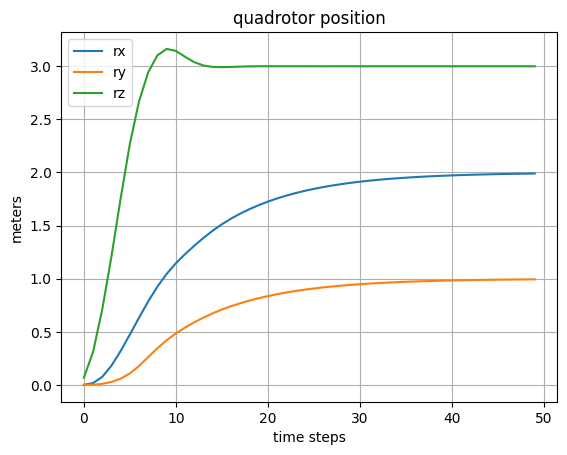

In [34]:
# drone position
plt.plot(x0vec[3,:].T,label='rx')
plt.plot(x0vec[4,:].T,label='ry')
plt.plot(x0vec[2,:].T,label='rz')
plt.grid()
plt.xlabel('time steps')
plt.ylabel('meters')
plt.legend()
plt.title('quadrotor position')
plt.show()

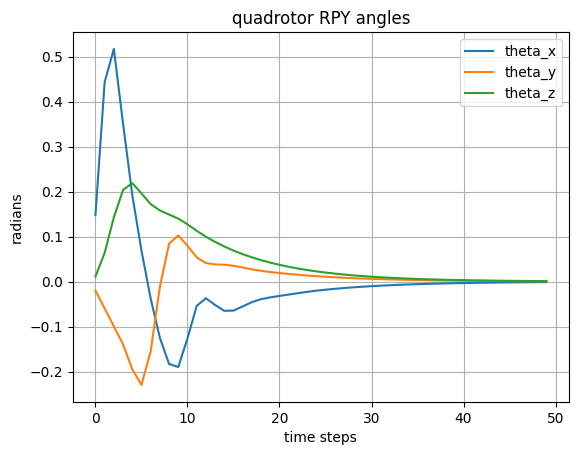

In [35]:
#  angles
plt.plot(x0vec[0,:].T,label='theta_x')
plt.plot(x0vec[1,:].T,label='theta_y')
plt.plot(x0vec[5,:].T,label='theta_z')
plt.grid()
plt.xlabel('time steps')
plt.ylabel('radians')
plt.title('quadrotor RPY angles')
plt.legend()
plt.show()

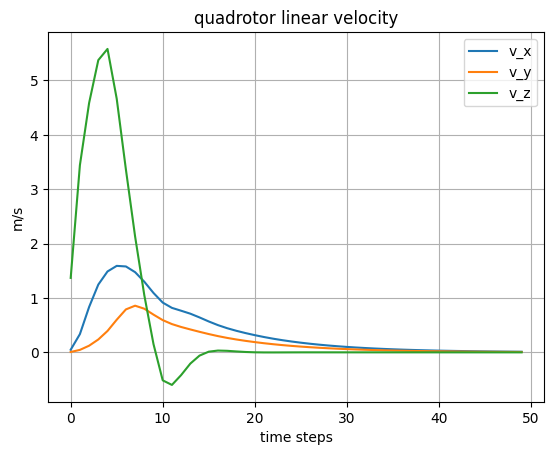

In [36]:
# linear velocity
plt.plot(x0vec[9,:].T,label='v_x')
plt.plot(x0vec[10,:].T,label='v_y')
plt.plot(x0vec[8,:].T,label='v_z')
plt.grid()
plt.xlabel('time steps')
plt.ylabel('m/s')
plt.title('quadrotor linear velocity')
plt.legend()
plt.show()

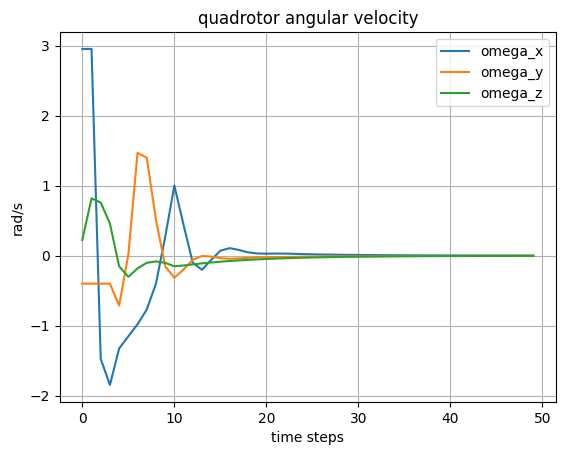

In [37]:
# angular velocity
plt.plot(x0vec[6,:].T,label='omega_x')
plt.plot(x0vec[7,:].T,label='omega_y')
plt.plot(x0vec[11,:].T,label='omega_z')
plt.grid()
plt.xlabel('time steps')
plt.ylabel('rad/s')
plt.title('quadrotor angular velocity')
plt.legend()
plt.show()

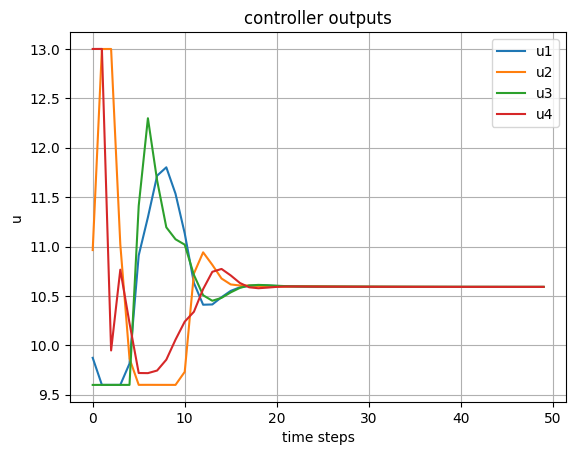

In [ ]:
# quadrotor control 
plt.plot(u0+u0vec.T) # must add nominal thrust u0
# plt.plot(u0vec.T)
plt.xlabel('time steps')
plt.ylabel('u')
plt.legend(['u1','u2','u3','u4'])
plt.title('controller outputs')
plt.grid()
plt.show()

***

<a id="p2"></a>

## P2 (3 คะแนน)

หากต้องการให้โดรนตามรอยแนววิถีเชิงเส้นโดยเริ่มต้นจากตำแหน่ง $[0,0,0]$ และเพิ่มค่าในแต่ละขั้นเวลาด้วยค่าเวกเตอร์ $d_p = [0.02, 0.01, 0.03]$ หาค่าตัวควบคุมเหมาะที่สุด และเวกเตอร์สถานะ พล็อตค่าสถานะ (4 พล็อต) และตัวควบคุมดังเช่นโจทย์ข้อ P2


### Solution

ในการหาคำตอบของโจทย์ข้อนี้ทำได้โดยกำหนดสถานะอ้างอิงเริ่มต้น

```python
xr = np.array([0.,0.,0.03,0.02,0.01,0.,0.,0.,0.,0.0,0.0,0.0]) 
```

และในการวนรอบ i แปรค่าสถานะอ้างอิงดังนี้

```python
xr = np.array([0.,0.,0.03*i,0.02*i,0.01*i,0.,0.,0.,0.3,0.2,0.1,0.0])
```

สังเกตว่าเรามีการกำหนดค่าความเร็วเชิงเส้นน้อยๆ ในสถานะอ้างอิง เพื่อความต่อเนื่องในการบิน อาจทดลองไม่กำหนดค่าความเร็วนี้ก็ได้ จะพบว่าแนววิถีมีการแกว่งมากกว่า

รันเซลล์ด้านล่างนี้เพื่อเก็บค่าสถานะ และพล็อต

In [41]:
# track trajectory
# Discrete time model of a quadcopter
Ad = sparse.csc_matrix([
  [1.,      0.,     0., 0., 0., 0., 0.1,     0.,     0.,  0.,     0.,     0.    ],
  [0.,      1.,     0., 0., 0., 0., 0.,      0.1,    0.,  0.,     0.,     0.    ],
  [0.,      0.,     1., 0., 0., 0., 0.,      0.,     0.1, 0.,     0.,     0.    ],
  [0.0488,  0.,     0., 1., 0., 0., 0.0016,  0.,     0.,  0.0992, 0.,     0.    ],
  [0.,     -0.0488, 0., 0., 1., 0., 0.,     -0.0016, 0.,  0.,     0.0992, 0.    ],
  [0.,      0.,     0., 0., 0., 1., 0.,      0.,     0.,  0.,     0.,     0.0992],
  [0.,      0.,     0., 0., 0., 0., 1.,      0.,     0.,  0.,     0.,     0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      1.,     0.,  0.,     0.,     0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      0.,     1.,  0.,     0.,     0.    ],
  [0.9734,  0.,     0., 0., 0., 0., 0.0488,  0.,     0.,  0.9846, 0.,     0.    ],
  [0.,     -0.9734, 0., 0., 0., 0., 0.,     -0.0488, 0.,  0.,     0.9846, 0.    ],
  [0.,      0.,     0., 0., 0., 0., 0.,      0.,     0.,  0.,     0.,     0.9846]
])
Bd = sparse.csc_matrix([
  [0.,      -0.0726,  0.,     0.0726],
  [-0.0726,  0.,      0.0726, 0.    ],
  [-0.0152,  0.0152, -0.0152, 0.0152],
  [-0.,     -0.0006, -0.,     0.0006],
  [0.0006,   0.,     -0.0006, 0.0000],
  [0.0106,   0.0106,  0.0106, 0.0106],
  [0,       -1.4512,  0.,     1.4512],
  [-1.4512,  0.,      1.4512, 0.    ],
  [-0.3049,  0.3049, -0.3049, 0.3049],
  [-0.,     -0.0236,  0.,     0.0236],
  [0.0236,   0.,     -0.0236, 0.    ],
  [0.2107,   0.2107,  0.2107, 0.2107]])
[nx, nu] = Bd.shape

# Constraints
u0 = 10.5916
umin = np.array([9.6, 9.6, 9.6, 9.6]) - u0
umax = np.array([13., 13., 13., 13.]) - u0
xmin = np.array([-np.pi/6,-np.pi/6,-np.inf,-np.inf,-np.inf,-1.,
                 -np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf])
xmax = np.array([ np.pi/6, np.pi/6, np.inf, np.inf, np.inf, np.inf,
                  np.inf, np.inf, np.inf, np.inf, np.inf, np.inf])

# Objective function
Q = sparse.diags([0., 0., 10., 10., 10., 10., 0., 0., 0., 5., 5., 5.])
QN = Q
R = 0.1*sparse.eye(4)

# Initial and reference states
x0 = np.zeros(12)
xr = np.array([0.,0.,0.03,0.02,0.01,0.,0.,0.,0.,0.0,0.0,0.0]) # changed to desired x,y,z


# Prediction horizon
N = 10

# Cast MPC problem to a QP: x = (x(0),x(1),...,x(N),u(0),...,u(N-1))
# - quadratic objective
P = sparse.block_diag([sparse.kron(sparse.eye(N), Q), QN,
                       sparse.kron(sparse.eye(N), R)], format='csc')
# - linear objective
q = np.hstack([np.kron(np.ones(N), -Q@xr), -QN@xr, np.zeros(N*nu)])
# - linear dynamics
Ax = sparse.kron(sparse.eye(N+1),-sparse.eye(nx)) + sparse.kron(sparse.eye(N+1, k=-1), Ad)
Bu = sparse.kron(sparse.vstack([sparse.csc_matrix((1, N)), sparse.eye(N)]), Bd)
Aeq = sparse.hstack([Ax, Bu])
leq = np.hstack([-x0, np.zeros(N*nx)])
ueq = leq
# - input and state constraints
Aineq = sparse.eye((N+1)*nx + N*nu)
lineq = np.hstack([np.kron(np.ones(N+1), xmin), np.kron(np.ones(N), umin)])
uineq = np.hstack([np.kron(np.ones(N+1), xmax), np.kron(np.ones(N), umax)])
# - OSQP constraints
A = sparse.vstack([Aeq, Aineq], format='csc')
l = np.hstack([leq, lineq])
u = np.hstack([ueq, uineq])

# Create an OSQP object
prob = osqp.OSQP()

# Setup workspace
prob.setup(P, q, A, l, u, warm_starting=True)

# Simulate in closed loop
nsim = 100
x0vec = np.zeros((12,nsim))
u0vec = np.zeros((4, nsim))
xrvec = np.zeros((3, nsim))
xrvec[:,0] = xr[2:5]
for i in range(nsim):
    # Solve
    res = prob.solve()

    # Check solver status
    if res.info.status != 'solved':
        raise ValueError('OSQP did not solve the problem!')

    # Apply first control input to the plant
    ctrl = res.x[-N*nu:-(N-1)*nu]
    x0 = Ad@x0 + Bd@ctrl
    x0vec[:,i] = x0
    u0vec[:,i] = ctrl

    # Update initial state
    l[:nx] = -x0
    u[:nx] = -x0

    # update reference 
    xr = np.array([0.,0.,0.03*i,0.02*i,0.01*i,0.,0.,0.,0.3,0.2,0.1,0.0]) # changed to desired x,y,z
    xrvec[:,i] = xr[2:5]
    # - linear objective
    q = np.hstack([np.kron(np.ones(N), -Q@xr), -QN@xr, np.zeros(N*nu)])
    prob.update(l=l, u=u,q=q)

-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 172, constraints m = 304
          nnz(P) + nnz(A) = 1161
settings: algebra = Built-in,
          OSQPInt = 8 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-03, eps_rel = 1.0e-03,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 4000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
          scaling: on (10 iterations), scaled_termination: off
          warm starting: on, polishing: off, 
iter   objective    prim res   dual res   gap        rel kkt    rho         time
   1  -5.0667e-02   5.03e-02   1.80e-01   8.38e-02   1.

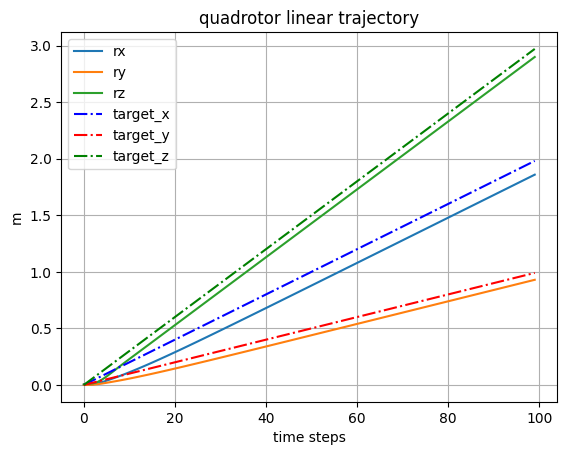

In [19]:
# trajectory plot
plt.plot(x0vec[3,:].T,label='rx')
plt.plot(x0vec[4,:].T,label='ry')
plt.plot(x0vec[2,:].T,label='rz')

plt.plot(xrvec[1,:].T,'b-.',label='target_x')
plt.plot(xrvec[2,:].T,'r-.',label='target_y')
plt.plot(xrvec[0,:].T,'g-.',label='target_z')
plt.grid()
plt.xlabel('time steps')
plt.ylabel('m')
plt.title('quadrotor linear trajectory')
plt.legend()
plt.show()

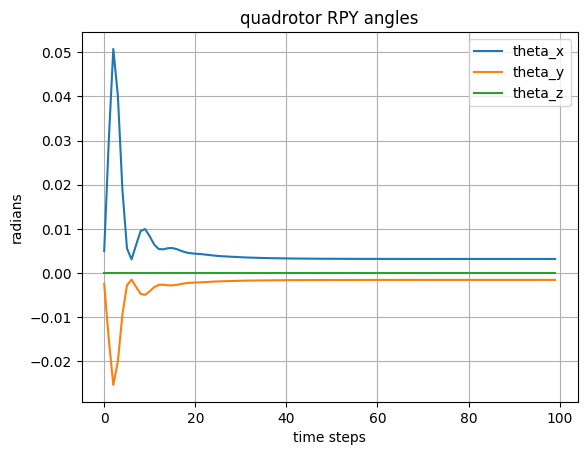

In [20]:
#  angles
plt.plot(x0vec[0,:].T,label='theta_x')
plt.plot(x0vec[1,:].T,label='theta_y')
plt.plot(x0vec[5,:].T,label='theta_z')
plt.grid()
plt.xlabel('time steps')
plt.ylabel('radians')
plt.title('quadrotor RPY angles')
plt.legend()
plt.show()

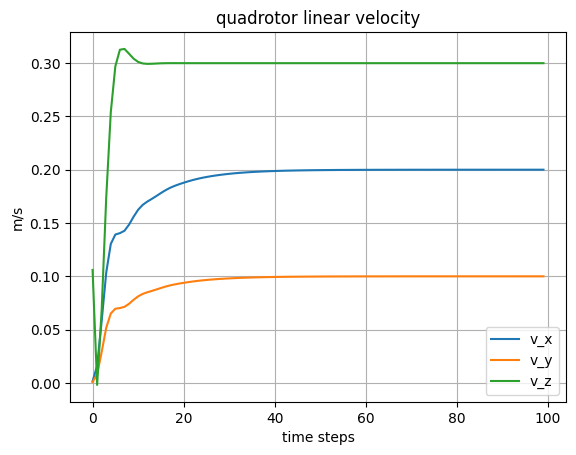

In [21]:
# linear velocity
plt.plot(x0vec[9,:].T,label='v_x')
plt.plot(x0vec[10,:].T,label='v_y')
plt.plot(x0vec[8,:].T,label='v_z')
plt.grid()
plt.xlabel('time steps')
plt.ylabel('m/s')
plt.title('quadrotor linear velocity')
plt.legend()
plt.show()

**หมายเหตุ :** สังเกตว่าความเร็วเชิงเส้นเข้าสู่ค่าที่กำหนดในสถานะอ้างอิง เป็นการยืนยันว่านิยามสถานะสำหรับความเร็วเชิงเส้นถูกต้อง

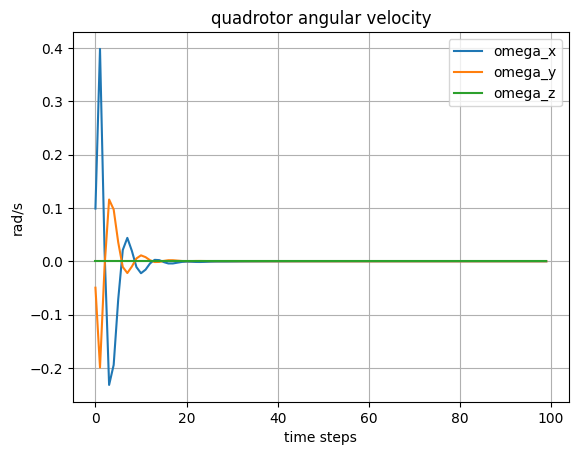

In [22]:
# angular velocity
plt.plot(x0vec[6,:].T,label='omega_x')
plt.plot(x0vec[7,:].T,label='omega_y')
plt.plot(x0vec[11,:].T,label='omega_z')
plt.grid()
plt.xlabel('time steps')
plt.ylabel('rad/s')
plt.title('quadrotor angular velocity')
plt.legend()
plt.show()

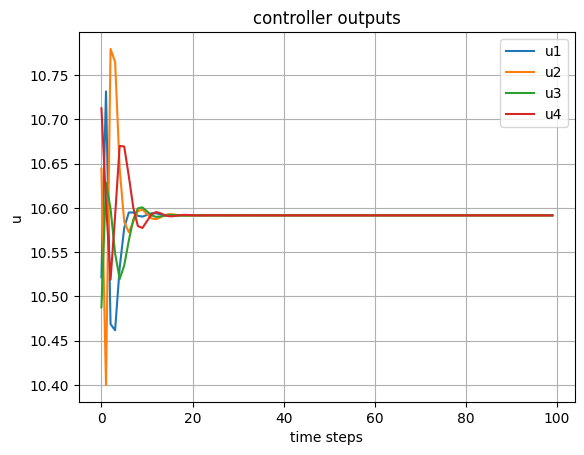

In [42]:
# quadrotor control 
plt.plot(u0 + u0vec.T) # must add nominal thrust u0
plt.xlabel('time steps')
plt.ylabel('u')
plt.legend(['u1','u2','u3','u4'])
plt.title('controller outputs')
plt.grid()
plt.show()

***

<a id="p3"></a>

## P3 (2 คะแนน)

จำลองการบินของโดรนตามแนววิถีที่สร้างในข้อ P2 โดยใช้ meshcat (สามารถใช้โมเดลของโดรน 3 มิติในบทที่ 6)

### Solution

ใช้โค้ดการจำลอง meshcat จากบทที่ 6

In [24]:
import meshcat
import meshcat.geometry as geo
import meshcat.transformations as tf
import time

In [25]:
# Create a new visualizer
vis = meshcat.Visualizer()

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7002/static/


In [26]:
base_height = 0.025
base_radius = 0.06
link_thick = 0.02
link_length = 0.46
rotor_height = 0.005
rotor_radius = 0.13
rotor_offset = link_thick
def build_quadrotor(vis):
    quadrotor = vis["quadrotor"]
    quadrotor.delete()
    base = quadrotor["base"]
    link1 = base["link1"]
    link2 = base["link2"]
    rotor1 = base["rotor1"]
    rotor2 = base["rotor2"]
    rotor3 = base["rotor3"]
    rotor4 = base["rotor4"]    
    base.set_object(geo.Cylinder(height=base_height,radius=base_radius))
    link1.set_object(geo.Box([link_length,link_thick,link_thick]))
    link2.set_object(geo.Box([link_thick,link_thick,link_length]))
    rotor1.set_object(geo.Cylinder(height=rotor_height,radius=rotor_radius))
    rotor1.set_transform(tf.translation_matrix([link_length/2,rotor_offset,0]))
    rotor2.set_object(geo.Cylinder(height=rotor_height,radius=rotor_radius))
    rotor2.set_transform(tf.translation_matrix([0,rotor_offset,-link_length/2]))
    rotor3.set_object(geo.Cylinder(height=rotor_height,radius=rotor_radius))
    rotor3.set_transform(tf.translation_matrix([-link_length/2,rotor_offset,0]))
    rotor4.set_object(geo.Cylinder(height=rotor_height,radius=rotor_radius))
    rotor4.set_transform(tf.translation_matrix([0,rotor_offset,link_length/2]))
    base.set_transform(tf.rotation_matrix(np.pi/2,[1,0,0]))
    return base

In [27]:
quadrotor = build_quadrotor(vis)

In [28]:
def update_quadrotor(base,r,axis,angle):
    offset = np.pi/2
    base.set_transform(tf.translation_matrix(r).dot(tf.rotation_matrix(offset,[1,0,0]).dot(tf.rotation_matrix(angle,axis))))    

def animate_quadrotor():
    for k in range(Nt):
        update_quadrotor(quadrotor,rvec[:,k],quadrotor_axis[:,k],quadrotor_angle[k])
        time.sleep(0.1)

นำสถานะที่ต้องการสร้างภาพยนต์ คือตำแหน่ง และมุม มาใส่ในเวกเตอร์ต่างหากเพื่อสะดวกในการเรียกใช้งาน

In [29]:
Nt = x0vec.shape[1]
# position vector
rxvec = x0vec[3,:].reshape(1,Nt)
ryvec = x0vec[4,:].reshape(1,Nt)
rzvec = x0vec[2,:].reshape(1,Nt)
rvec = np.vstack((rxvec,ryvec,rzvec))
# theta_vector
thxvec = x0vec[0,:].reshape(1,Nt)
thyvec = x0vec[1,:].reshape(1,Nt)
thzvec = x0vec[5,:].reshape(1,Nt)
thvec = np.vstack((thxvec,thyvec,thzvec))

โมเดล meshcat ที่ใช้ในบทที่ 6 รับข้อมูลในรูปเวกเตอร์ - มุม ดังนั้นต้องแปลงจาก RPY ก่อนโดยใช้วิธีการดังนี้

In [30]:
# need to transform RPY to angle vector
from scipy.spatial.transform import Rotation as R
rotation = R.from_euler('xyz',thvec.T, degrees=False)
axis_angle_vector = rotation.as_rotvec().T
quadrotor_angle = np.linalg.norm(axis_angle_vector,axis=0)
quadrotor_axis = axis_angle_vector/quadrotor_angle


รันเซลล์ด้านล่างนี้เพื่อสร้างภาพยนต์การบินของควอดโรเตอร์

In [32]:
update_quadrotor(quadrotor,rvec[:,0],quadrotor_axis[:,0],quadrotor_angle[0])
animate_quadrotor()

ขั้นต่ำคือต้องการให้สร้างภาพยนต์สำหรับแนววิถีตาม P2 แต่เราอาจสร้างภาพยนต์สำหรับทั้ง P1 และ P2 เปรียบเทียบกันก็ได้ ทำให้เห็นแนววิถีการบินที่แตกต่างกัน ดังที่บันทึกไว้ใน [วีดีโอนี้](https://youtu.be/K3VlTHZYdpM)



<div align="right">Rev 1A : 31 มกราคม 2569</div>

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>